In [1]:
# Import the required library
import numpy as np
import pandas as pd
from skimage import io
from PIL import Image
import matplotlib.pyplot as plt

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=4080x3060 at 0x71868D6221D0>
Image shape: (3060, 4080)
[[219. 217. 214. ... 221. 220. 222.]
 [217. 216. 215. ... 222. 221. 221.]
 [218. 217. 216. ... 222. 222. 219.]
 ...
 [ 58.  58.  61. ... 121. 130. 129.]
 [ 58.  60.  60. ...  90. 127. 122.]
 [ 61.  63.  59. ...  63.  94.  96.]]


(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

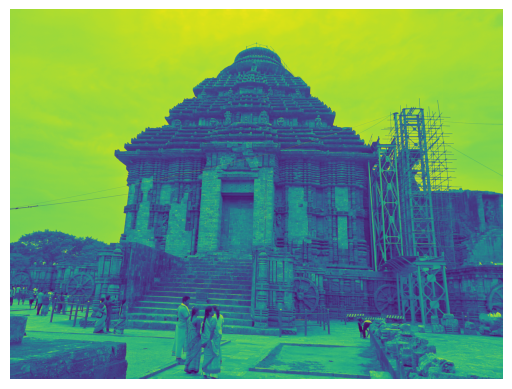

In [2]:
# Image path
img_path = "konark.jpg"

# Load image
img = Image.open(img_path)
print(img)

# Convert to grayscale
gray_image = img.convert("L")

# Convert to NumPy matrix (float)
img_mat = np.array(gray_image, dtype=float)

# Print shape
print("Image shape:", img_mat.shape)

# Display image
plt.imshow(img_mat)
print(img_mat)
plt.axis("off")

In [3]:
# Scale the image matrix before SVD
img_mat_scaled = (img_mat - img_mat.mean())/img_mat.std()
img_mat_scaled

array([[ 1.09609611,  1.06873921,  1.02770385, ...,  1.12345301,
         1.10977456,  1.13713147],
       [ 1.06873921,  1.05506076,  1.0413823 , ...,  1.13713147,
         1.12345301,  1.12345301],
       [ 1.08241766,  1.06873921,  1.05506076, ...,  1.13713147,
         1.13713147,  1.09609611],
       ...,
       [-1.10613463, -1.10613463, -1.06509928, ..., -0.24439217,
        -0.1212861 , -0.13496455],
       [-1.10613463, -1.07877773, -1.07877773, ..., -0.66842417,
        -0.16232146, -0.23071372],
       [-1.06509928, -1.03774237, -1.09245618, ..., -1.03774237,
        -0.61371037, -0.58635346]], shape=(3060, 4080))

In [4]:
# Performed SVD using np.linalg.svd
U,s,V = np.linalg.svd(img_mat_scaled)
print(U)

[[ 0.03165277  0.00632979  0.020401   ...  0.05115104 -0.07423666
   0.01271198]
 [ 0.03163969  0.00633999  0.02039665 ... -0.12728172  0.11338647
  -0.12535878]
 [ 0.03161615  0.00631137  0.02031403 ...  0.22767054 -0.10342576
   0.1699972 ]
 ...
 [-0.00797437  0.02107741 -0.01400424 ... -0.00211963 -0.001987
  -0.00198232]
 [-0.00784022  0.02195307 -0.01370946 ... -0.00297071  0.00031196
   0.00318498]
 [-0.0078588   0.02225559 -0.01361145 ...  0.00423028  0.0034702
  -0.00157931]]


In [5]:
print(s)

[2.46698774e+03 1.62336455e+03 8.43637488e+02 ... 1.68621834e-01
 1.66052090e-01 1.60507680e-01]


In [6]:
print(V)

[[ 0.01385685  0.01384571  0.01383498 ...  0.01532969  0.01536453
   0.01540119]
 [-0.02101575 -0.02094014 -0.02093324 ... -0.01148853 -0.01136444
  -0.01119687]
 [ 0.01572364  0.01570332  0.01554854 ... -0.01161253 -0.0121004
  -0.01241082]
 ...
 [-0.04033421  0.01652277 -0.02232029 ...  0.40546188 -0.16900017
   0.0059357 ]
 [ 0.00495053 -0.00458933  0.01164967 ... -0.17875605  0.42707087
  -0.21043399]
 [ 0.00791486 -0.00317748  0.00302908 ...  0.02296656 -0.22615729
   0.27059366]]


In [7]:
# Compute Variance explained by each singular vector
var_explained = np.round(s**2/np.sum(s**2), decimals = 3)
var_explained

array([0.487, 0.211, 0.057, ..., 0.   , 0.   , 0.   ], shape=(3060,))

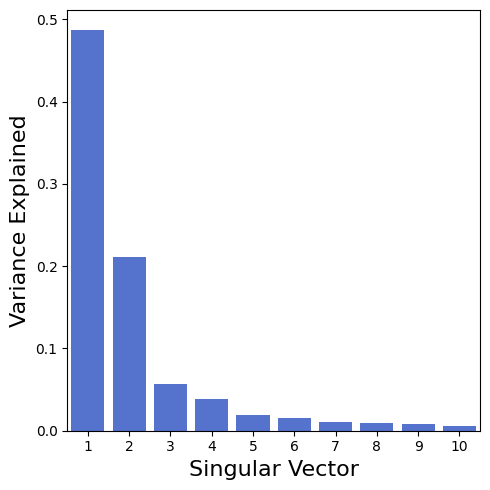

In [8]:
import seaborn as sns
plt.figure(figsize=(5, 5))

sns.barplot(
    x=list(range(1, 11)),
    y=var_explained[:10],
    color="royalblue"
)

plt.xlabel('Singular Vector', fontsize=16)
plt.ylabel('Variance Explained', fontsize=16)
plt.tight_layout()
plt.savefig('svd_scree_plot.png', dpi=150)
plt.show()

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

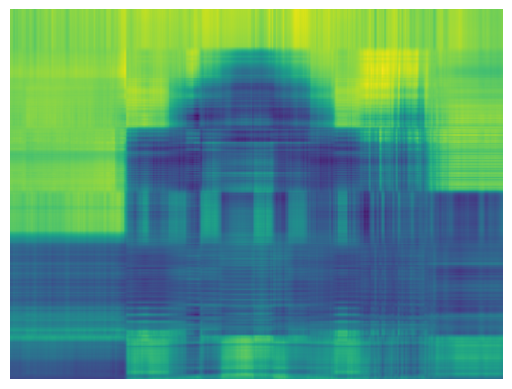

In [62]:
num_components = 5

U_k = U[:, :num_components]                 
S_k = np.diag(s[:num_components])           
Vt_k = V[:num_components, :]               

reconst_img_5 = U_k @ S_k @ Vt_k
plt.imshow(reconst_img_5)
plt.axis("off")

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

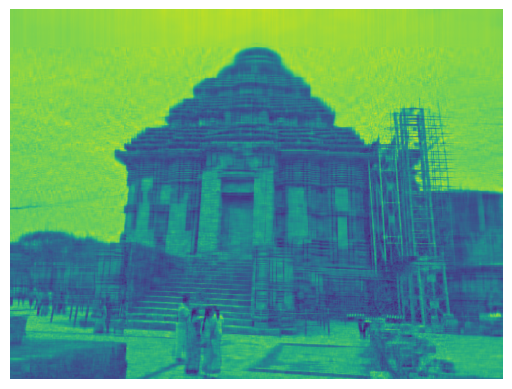

In [63]:
num_components = 50

U_k = U[:, :num_components]                 
S_k = np.diag(s[:num_components])           
Vt_k = V[:num_components, :]               

reconst_img_50 = U_k @ S_k @ Vt_k
plt.imshow(reconst_img_50)
plt.axis("off")

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

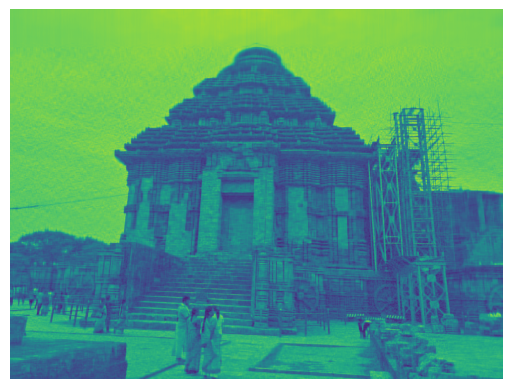

In [64]:
num_components = 100

U_k = U[:, :num_components]                 
S_k = np.diag(s[:num_components])           
Vt_k = V[:num_components, :]               

reconst_img_100 = U_k @ S_k @ Vt_k
plt.imshow(reconst_img_100)
plt.axis("off")

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

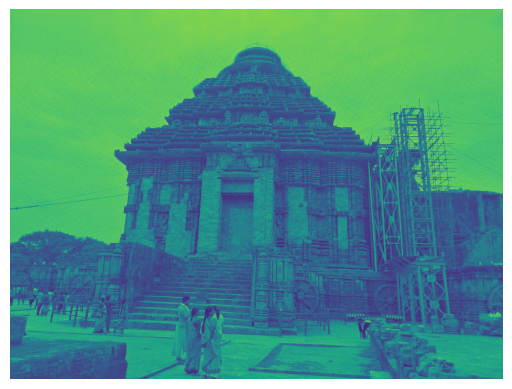

In [65]:
num_components = 200

U_k = U[:, :num_components]                 
S_k = np.diag(s[:num_components])           
Vt_k = V[:num_components, :]               

reconst_img_200 = U_k @ S_k @ Vt_k
plt.imshow(reconst_img_200)
plt.axis("off")

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

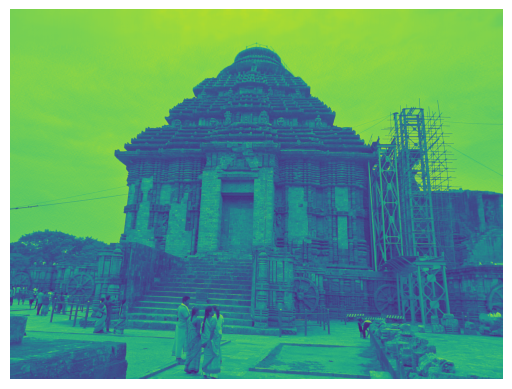

In [66]:
num_components = 400

U_k = U[:, :num_components]                 
S_k = np.diag(s[:num_components])           
Vt_k = V[:num_components, :]               

reconst_img_400 = U_k @ S_k @ Vt_k
plt.imshow(reconst_img_400)
plt.axis("off")

(np.float64(-0.5), np.float64(4079.5), np.float64(3059.5), np.float64(-0.5))

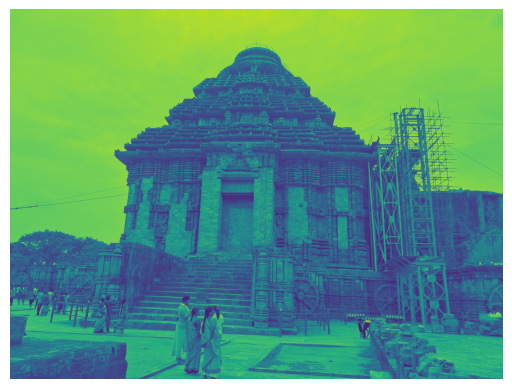

In [67]:
num_components = 650

U_k = U[:, :num_components]                 
S_k = np.diag(s[:num_components])           
Vt_k = V[:num_components, :]              

reconst_img_650 = U_k @ S_k @ Vt_k
plt.imshow(reconst_img_650)
plt.axis("off")

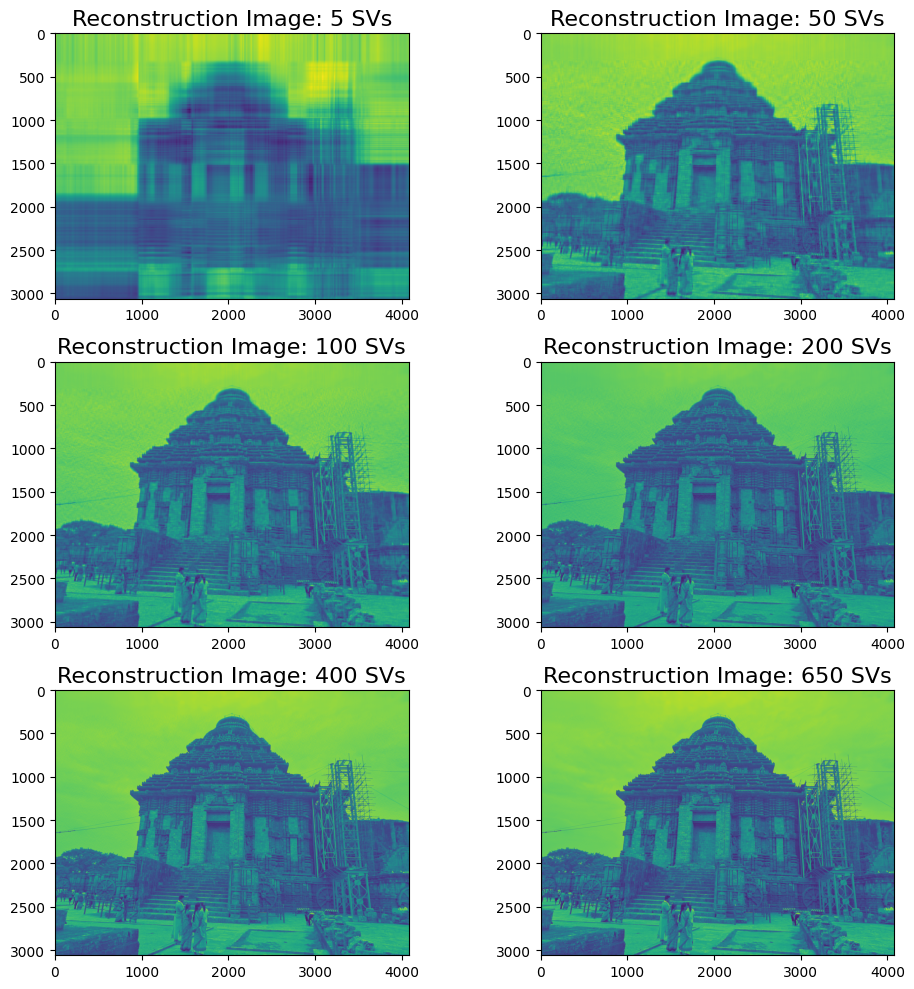

In [68]:
fig, axs = plt.subplots(3,2,figsize = (10,10))
axs[0,0].imshow(reconst_img_5)
axs[0,0].set_title('Reconstruction Image: 5 SVs', size = 16)
axs[0,1].imshow(reconst_img_50)
axs[0,1].set_title('Reconstruction Image: 50 SVs', size = 16)
axs[1,0].imshow(reconst_img_100)
axs[1,0].set_title('Reconstruction Image: 100 SVs', size = 16)
axs[1,1].imshow(reconst_img_200)
axs[1,1].set_title('Reconstruction Image: 200 SVs', size = 16)
axs[2,0].imshow(reconst_img_400)
axs[2,0].set_title('Reconstruction Image: 400 SVs', size = 16)
axs[2,1].imshow(reconst_img_650)
axs[2,1].set_title('Reconstruction Image: 650 SVs', size = 16)
plt.tight_layout()